In [1]:
import pandas as pd
import re
import nltk

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.corpus import stopwords

print("Library berhasil di-import!")

Library berhasil di-import!


In [2]:
df = pd.read_csv(
    "dataset_detik.csv",
    sep=";",
    encoding="utf-8-sig"
)

print("Dataset berhasil dibaca!")
print("Jumlah data:", len(df))
print("Jumlah kolom:", len(df.columns))

display(df.head())

Dataset berhasil dibaca!
Jumlah data: 200
Jumlah kolom: 3


,id,isi_berita,label
0,1,Ciamis - Sebanyak 549 siswa dari 40 SD mengiku...,sport
1,2,"Dalam dua seri terakhir MotoGP 2027, Marc Marq...",sport
2,3,"Alwi Farhan, Moh Zaki Ubaidillah dan Muhamad Y...",sport
3,4,Di tengah viral insiden cepirit pada ajang Hyr...,sport
4,5,Dejan Fedinansyah/Felisha Alberta Nathaniel Pa...,sport


In [3]:
print("Contoh berita sebelum preprocessing:\n")
print(df["isi_berita"].iloc[0])

print("\nPanjang teks berita pertama:")
print(len(df["isi_berita"].iloc[0]))

print("\nDistribusi label:")
print(df["label"].value_counts())

Contoh berita sebelum preprocessing:

Ciamis - Sebanyak 549 siswa dari 40 SD mengikuti lomba olahraga tradisional di Ciamis, Jawa Barat, dengan penuh semangat.
Sejumlah peserta beradu cepat dalam lomba olahraga tradisional (Oltrad) egrang di Lapang Cigorowong, Kabupaten Ciamis, Jawa Barat, Rabu (16/9/2026). Para siswa beradu kemampuan dalam lima cabang olahraga tradisional, yakni hadang, terompah panjang, dagongan, sumpitan, dan egrang. Setiap pertandingan menghadirkan keseruan sekaligus mengajak peserta mengenal permainan tradisional. ANTARA FOTO/Adeng Bustomi
Salah satu perlombaan yang menarik perhatian adalah dagongan. Dalam pertandingan tersebut, peserta saling mendorong batang bambu dengan mengandalkan kekuatan, keseimbangan, dan kerja sama tim. ANTARA FOTO/Adeng Bustomi
Kejuaraan olahraga tradisional tersebut menjadi sarana edukasi bagi siswa sekaligus bagian dari upaya melestarikan budaya. Melalui kegiatan ini, olahraga tradisional dikenalkan kepada generasi muda agar tetap dima

In [4]:
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\LENOVO\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


True

In [5]:
stop_words = set(stopwords.words("indonesian"))

factory = StemmerFactory()
stemmer = factory.create_stemmer()

print("Jumlah stopword:", len(stop_words))
print("Stemmer Bahasa Indonesia berhasil dibuat!")

Jumlah stopword: 757
Stemmer Bahasa Indonesia berhasil dibuat!


In [6]:
# membuat Fungsi Prepocessing
def preprocessing_teks(teks):
    # 1. Case folding
    teks = teks.lower()

    # 2. Menghapus URL
    teks = re.sub(r"http\S+|www\S+", "", teks)

    # 3. Menghapus angka
    teks = re.sub(r"\d+", "", teks)

    # 4. Menghapus tanda baca dan karakter khusus
    teks = re.sub(r"[^a-zA-Z\s]", " ", teks)

    # 5. Menghapus spasi berlebih
    teks = re.sub(r"\s+", " ", teks).strip()

    # 6. Tokenisasi sederhana
    tokens = teks.split()

    # 7. Stopword removal
    tokens = [kata for kata in tokens if kata not in stop_words]

    # 8. Stemming Bahasa Indonesia
    tokens = [stemmer.stem(kata) for kata in tokens]

    # Menggabungkan kembali menjadi teks
    return " ".join(tokens)


print("Fungsi preprocessing berhasil dibuat!")

Fungsi preprocessing berhasil dibuat!


In [7]:
df["teks_preprocessed"] = df["isi_berita"].apply(preprocessing_teks)

print("Preprocessing selesai!")
display(df[["id", "isi_berita", "teks_preprocessed", "label"]].head())

Preprocessing selesai!


,id,isi_berita,teks_preprocessed,label
0,1,Ciamis - Sebanyak 549 siswa dari 40 SD mengiku...,ciamis siswa sd ikut lomba olahraga tradisiona...,sport
1,2,"Dalam dua seri terakhir MotoGP 2027, Marc Marq...",seri motogp marc marquez sukses sapu bersih po...,sport
2,3,"Alwi Farhan, Moh Zaki Ubaidillah dan Muhamad Y...",alwi farhan moh zaki ubaidillah muhamad yusuf ...,sport
3,4,Di tengah viral insiden cepirit pada ajang Hyr...,viral insiden cepirit ajang hyrox atlet malays...,sport
4,5,Dejan Fedinansyah/Felisha Alberta Nathaniel Pa...,dejan fedinansyah felisha alberta nathaniel pa...,sport


In [8]:
# Ektrak Kata Unik
from sklearn.feature_extraction.text import TfidfVectorizer

# Membuat objek TF-IDF
vectorizer = TfidfVectorizer()

# Mengubah teks hasil preprocessing menjadi matriks TF-IDF
tfidf_matrix = vectorizer.fit_transform(df["teks_preprocessed"])

print("TF-IDF berhasil dibuat!")
print("Jumlah dokumen :", tfidf_matrix.shape[0])
print("Jumlah fitur/kata unik :", tfidf_matrix.shape[1])

TF-IDF berhasil dibuat!
Jumlah dokumen : 200
Jumlah fitur/kata unik : 5068


In [11]:
fitur_kata = vectorizer.get_feature_names_out()

print("Jumlah seluruh kata unik:", len(fitur_kata))
print("\n10 kata unik pertama:")
print(fitur_kata[:10])

Jumlah seluruh kata unik: 5068

10 kata unik pertama:
['aaa' 'aau' 'ab' 'abad' 'abadi' 'abai' 'abal' 'abdullah' 'abdurrahkman'
 'abet']


In [12]:
from sklearn.decomposition import PCA

# Mengubah matriks TF-IDF menjadi bentuk dense
tfidf_dense = tfidf_matrix.toarray()

# Membuat PCA menjadi 2 dimensi
pca = PCA(n_components=2)

# Melakukan reduksi dimensi
tfidf_pca = pca.fit_transform(tfidf_dense)

print("PCA berhasil dilakukan!")
print("Ukuran data sebelum PCA :", tfidf_dense.shape)
print("Ukuran data setelah PCA :", tfidf_pca.shape)

print("\nExplained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("\nTotal Explained Variance:")
print(pca.explained_variance_ratio_.sum())

PCA berhasil dilakukan!
Ukuran data sebelum PCA : (200, 5068)
Ukuran data setelah PCA : (200, 2)

Explained Variance Ratio:
[0.04738586 0.03139293]

Total Explained Variance:
0.07877879387673234


In [13]:
df_pca = pd.DataFrame(
    tfidf_pca,
    columns=["PC1", "PC2"]
)

# Menambahkan label berita
df_pca["label"] = df["label"].values

print("Data hasil PCA:")
display(df_pca.head())

Data hasil PCA:


,PC1,PC2,label
0,-0.051591,-0.084697,sport
1,0.476904,0.043437,sport
2,-0.090812,-0.309347,sport
3,-0.035141,-0.060507,sport
4,-0.096658,-0.327154,sport


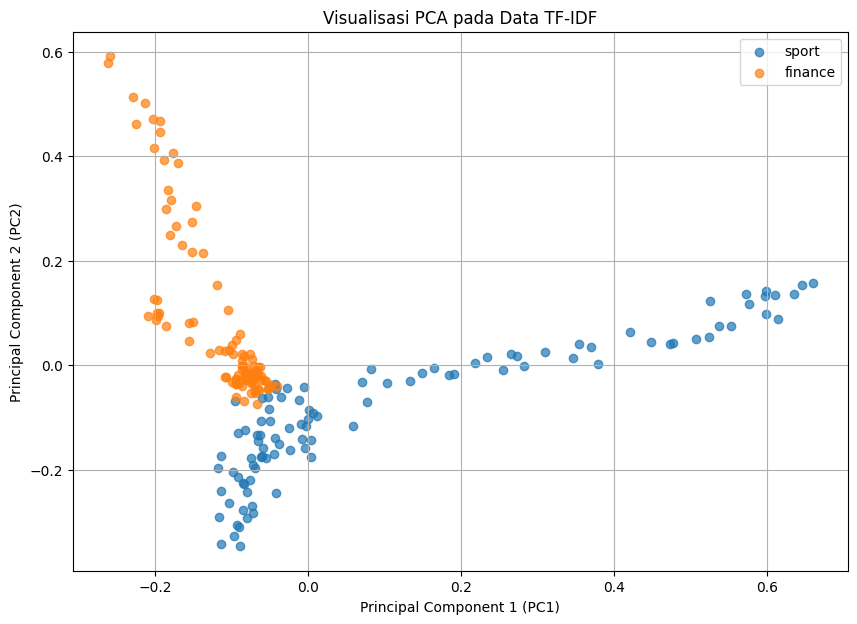

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

for label in df_pca["label"].unique():
    data = df_pca[df_pca["label"] == label]

    plt.scatter(
        data["PC1"],
        data["PC2"],
        label=label,
        alpha=0.7
    )

plt.title("Visualisasi PCA pada Data TF-IDF")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend()
plt.grid(True)
plt.show()

In [15]:
from sklearn.decomposition import PCA
import numpy as np

# PCA tanpa menentukan jumlah komponen
pca_full = PCA()

# Melatih PCA pada data TF-IDF
pca_full.fit(tfidf_dense)

# Menghitung cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Mencari jumlah komponen yang mempertahankan minimal 90% variasi
jumlah_komponen_90 = np.argmax(cumulative_variance >= 0.90) + 1

print("Jumlah komponen untuk mempertahankan 90% variasi:",
      jumlah_komponen_90)

print("Explained variance pada jumlah komponen tersebut:",
      cumulative_variance[jumlah_komponen_90 - 1])

Jumlah komponen untuk mempertahankan 90% variasi: 138
Explained variance pada jumlah komponen tersebut: 0.9023612585721619


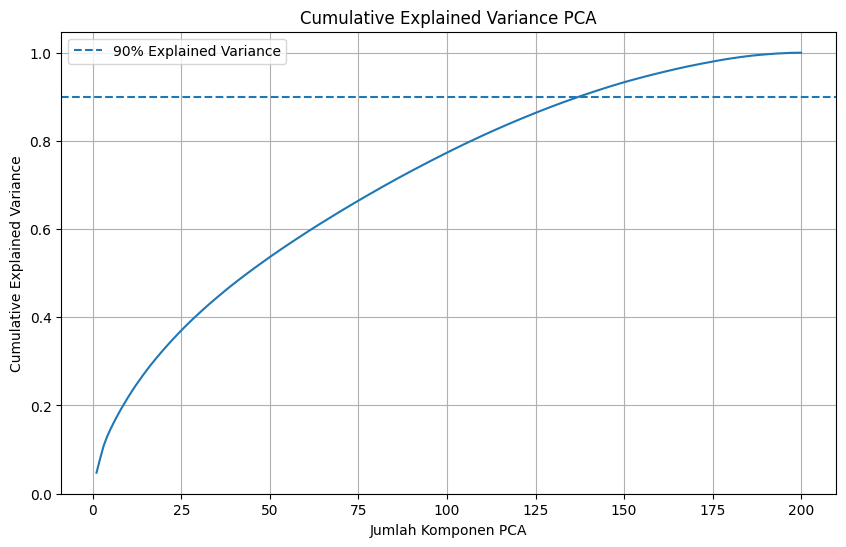

In [16]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance
)

plt.axhline(
    y=0.90,
    linestyle="--",
    label="90% Explained Variance"
)

plt.xlabel("Jumlah Komponen PCA")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance PCA")
plt.legend()
plt.grid(True)
plt.show()